## Step 1: Data Collection

In [1]:
   import numpy as np
   import pandas as pd
   import matplotlib.pyplot as plt
   import seaborn as sns
   import statsmodels.api as sm
   import sklearn
   import joblib

   print("All imports OK")
   print("pandas", pd.__version__, "| sklearn", sklearn.__version__)

All imports OK
pandas 3.0.6 | sklearn 1.9.1


In [2]:
df = pd.read_csv("../data/Loan.csv")   # notebook is inside notebooks/
print(df.shape)                        # expect about (20000, 36)
df.head()

(20000, 36)


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
print(df.columns.tolist())
df.info()

['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  str    
 1   Age                    

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


count    20000.000000
mean        50.766780
std          7.778262
min         28.800000
25%         46.000000
50%         52.000000
75%         56.000000
max         84.000000
Name: RiskScore, dtype: float64
Missing: 0
Unique values: 73


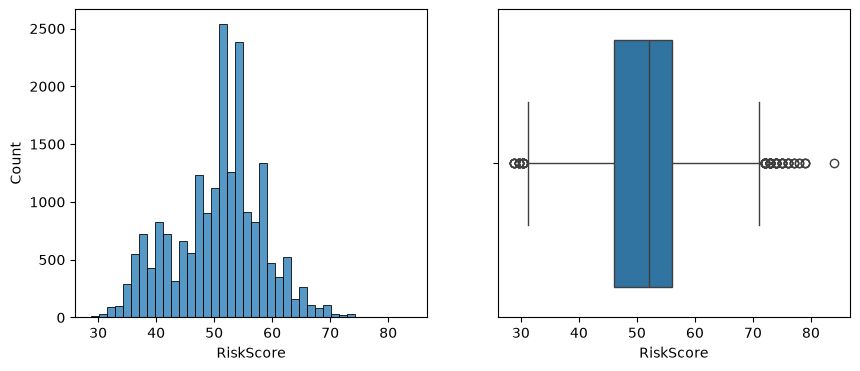

In [5]:
print(df["RiskScore"].describe())
print("Missing:", df["RiskScore"].isna().sum())
print("Unique values:", df["RiskScore"].nunique())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["RiskScore"], bins=40, ax=ax[0])
sns.boxplot(x=df["RiskScore"], ax=ax[1])
plt.show()

In [6]:
pd.set_option("display.max_rows", None)
df.describe().T[["min", "50%", "max"]]

,min,50%,max
Age,18.000000,40.000000,8.000000e+01
AnnualIncome,15000.000000,48566.000000,4.853410e+05
CreditScore,343.000000,578.000000,7.120000e+02
Experience,0.000000,17.000000,6.100000e+01
LoanAmount,3674.000000,21914.500000,1.847320e+05
LoanDuration,12.000000,48.000000,1.200000e+02
NumberOfDependents,0.000000,1.000000,5.000000e+00
MonthlyDebtPayments,50.000000,402.000000,2.919000e+03
CreditCardUtilizationRate,0.000974,0.266673,9.173801e-01
NumberOfOpenCreditLines,0.000000,3.000000,1.300000e+01


In [7]:
print("Experience > Age:", (df["Experience"] > df["Age"]).sum())
print(df[["AnnualIncome", "LoanAmount", "MonthlyDebtPayments"]].quantile([0.5, 0.99, 0.999]))

Experience > Age: 0
       AnnualIncome  LoanAmount  MonthlyDebtPayments
0.500      48566.00   21914.500              402.000
0.990     211041.33   70130.080             1269.000
0.999     300000.00  110702.726             1846.004


### Data Dictionary

- **Target:** `RiskScore`
- **Rows:** 20,000
- **Missing values:** none
- **Ranges:** min / median / max from `df.describe()`

#### Columns used

| Column | Type | Meaning | Min / Median / Max | Notes |
|:---|:---|:---|:---|:---|
| `RiskScore` | float | **Target.** Borrower risk score. Higher means riskier. | 28.8 / 52 / 84 | Bell-shaped but spiky. Only 73 unique values. A few mild outliers. Likely built from a formula. |
| `CreditScore` | int | Borrower's credit score. | 343 / 578 / 712 | Within the normal 300 to 850 range. |
| `AnnualIncome` | int | Yearly income. | 15,000 / 48,566 / 485,341 | Long right tail. 99.9% of rows are at or below 300,000. |
| `DebtToIncomeRatio` | float | Share of income going to debt. | 0.002 / 0.264 / 0.902 | Stays between 0 and 1. |
| `LoanAmount` | int | Amount borrowed. | 3,674 / 21,915 / 184,732 | Long right tail, but smooth (no typo-like values). |
| `LoanDuration` | int | Length of the loan (likely months). | 12 / 48 / 120 | Whole numbers only. |
| `BankruptcyHistory` | int (0/1) | 1 = past bankruptcy. | 0 / 0 / 1 | Flag. Most borrowers are 0. |
| `PreviousLoanDefaults` | int (0/1) | 1 = defaulted on a past loan. | 0 / 0 / 1 | Flag. Most borrowers are 0. |
| `PaymentHistory` | int | Record of past payments (units not stated in the data). | 8 / 24 / 45 | Check its link to `RiskScore` in EDA before reading the direction. |
| `CreditCardUtilizationRate` | float | Share of credit card limit in use. | 0.001 / 0.267 / 0.917 | Stays between 0 and 1. |
| `EmploymentStatus` | text | Borrower's job status. | none | Becomes 0/1 columns in Step 2. |
| `LoanPurpose` | text | Why the loan is taken. | none | Becomes 0/1 columns in Step 2. |